# GCI Meta-Analysis: Concentration Precedes Fragility

**Objective**: Determine if Gamma Concentration Index (GCI) spikes predict outsized late-day SPX moves.

**Sample Period**: October - December 2024 (Q4)

**Focus**: Late-day moves (2:00-3:45 PM ET) that create asymmetric option payoffs.

**Key Question**: Does GCI > 0.30 predict outsized moves (>2.5σ) better than chance?

In [9]:
# ============================================================
# SETUP & CONFIGURATION
# ============================================================

import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, date, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Local data loader
from src.config import Config
from src.data_loader import DataLoader
from src.greeks import BlackScholesGreeks

# Configuration
config = Config()
loader = DataLoader(config)
available_dates = loader.get_available_dates()

from zoneinfo import ZoneInfo
ET = ZoneInfo('America/New_York')

# ============ ANALYSIS PARAMETERS ============
STUDY_START = "2024-10-01"  # Q4 2024 start
STUDY_END = "2024-12-31"    # Q4 2024 end

# GCI calculation
INTERVAL_MINUTES = 5
STRIKE_RANGE = 100

# GCI spike threshold
GCI_SPIKE_THRESHOLD = 0.30
GCI_BASELINE = 0.20

# Late-day focus window (ET)
LATE_DAY_START = "14:00"
LATE_DAY_END = "15:45"

# Outsized move definition
LOOKFORWARD_MINUTES = [15, 30, 45, 60]
SIGMA_THRESHOLD = 2.5
ABS_MOVE_THRESHOLD = 15

# Filter to study period
study_dates = [d.strftime('%Y-%m-%d') for d in available_dates
               if STUDY_START <= d.strftime('%Y-%m-%d') <= STUDY_END]

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Data dir: {config.data_dir}")
print(f"Total available dates: {len(available_dates)}")
print('=' * 60)
print('GCI META-ANALYSIS CONFIGURATION')
print('=' * 60)
print(f'Study Period: {STUDY_START} to {STUDY_END}')
print(f'Dates in study period: {len(study_dates)}')
print(f'GCI Spike Threshold: {GCI_SPIKE_THRESHOLD}')
print(f'Late-Day Window: {LATE_DAY_START} - {LATE_DAY_END} ET')
print(f'Outsized Move: >{SIGMA_THRESHOLD}sigma of 30-min RV')


GEX_ROOT: /Users/esaforrian/Documents/GitHub/Hermes/services/gex-analytics
GCI META-ANALYSIS CONFIGURATION
Study Period: 2025-12-24 to 2026-01-07
GCI Spike Threshold: 0.3
Late-Day Window: 14:00 - 15:45 ET
Outsized Move: >2.5σ of 30-min RV
Lookforward Windows: [15, 30, 45, 60] minutes

⚠️  NOTE: Analytics Bucket has ~7 day TTL
    For larger historical study, need backfill data


In [10]:
# ============================================================
# VERIFY DATA AVAILABILITY
# ============================================================

print(f'Study dates found: {len(study_dates)}')
if study_dates:
    print(f'  First: {study_dates[0]}')
    print(f'  Last: {study_dates[-1]}')
else:
    print('No data in study period! Check data/ directory and STUDY_START/STUDY_END.')


Querying Analytics Bucket for available dates...
Discovering available trade dates from Analytics Bucket...
  Found 9 dates: 2025-12-24 to 2026-01-07

Dates in study period: 9
  First: 2025-12-24
  Last: 2026-01-07


In [11]:
# ============================================================
# GCI CALCULATION FUNCTIONS
# ============================================================

from scipy.stats import norm

def calculate_gamma_vectorized(spot, strike, tte_years, sigma=0.20, rate=0.05):
    """Calculate gamma using Black-Scholes formula (vectorized)."""
    spot = np.asarray(spot, dtype=float)
    strike = np.asarray(strike, dtype=float)
    tte = np.asarray(tte_years, dtype=float)
    tte = np.maximum(tte, 1e-6)
    sqrt_tte = np.sqrt(tte)
    d1 = (np.log(spot / strike) + (rate + 0.5 * sigma**2) * tte) / (sigma * sqrt_tte)
    gamma = norm.pdf(d1) / (spot * sigma * sqrt_tte)
    return gamma


def calculate_interval_gci(df_interval, spot, strike_range=100):
    """Calculate GCI for a single interval."""
    if df_interval.empty:
        return {'gci': np.nan, 'pgr': np.nan, 'gamma_total': 0, 'dominant_strike': np.nan, 'n_strikes': 0}
    
    df_filtered = df_interval[
        (df_interval['strike'] >= spot - strike_range) &
        (df_interval['strike'] <= spot + strike_range)
    ].copy()
    
    if df_filtered.empty or len(df_filtered) < 10:
        return {'gci': np.nan, 'pgr': np.nan, 'gamma_total': 0, 'dominant_strike': np.nan, 'n_strikes': 0}
    
    if 'gamma' not in df_filtered.columns:
        df_filtered['gamma'] = calculate_gamma_vectorized(
            df_filtered['spot'].values, df_filtered['strike'].values, df_filtered['tte_years'].values
        )
    
    df_filtered['gamma_exp'] = df_filtered['gamma'].abs() * df_filtered['size'] * 100
    strike_gamma = df_filtered.groupby('strike')['gamma_exp'].sum()
    gamma_total = strike_gamma.sum()
    
    if gamma_total == 0 or len(strike_gamma) == 0:
        return {'gci': np.nan, 'pgr': np.nan, 'gamma_total': 0, 'dominant_strike': np.nan, 'n_strikes': 0}
    
    gamma_shares = strike_gamma / gamma_total
    gci = (gamma_shares ** 2).sum()
    
    near_spot_mask = strike_gamma.index.to_series().apply(lambda k: abs(k - spot) <= 20)
    gamma_near = strike_gamma[near_spot_mask].sum()
    pgr = gamma_near / gamma_total
    dominant_strike = strike_gamma.idxmax()
    
    return {'gci': gci, 'pgr': pgr, 'gamma_total': gamma_total, 'dominant_strike': dominant_strike, 'n_strikes': len(strike_gamma)}


def process_day_for_gci(trade_date, data_loader, interval_minutes=5, strike_range=100, verbose=False):
    """Process a single day and calculate GCI for each interval."""
    df = data_loader.load_trades_for_date(trade_date)
    
    if df.empty:
        if verbose: print(f'  No data for {trade_date}')
        return pd.DataFrame()
    
    required_cols = ['timestamp', 'strike', 'spot', 'size', 'tte_years']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        if verbose: print(f'  Missing columns: {missing}')
        return pd.DataFrame()
    
    df['timestamp_et'] = df['timestamp']
    df['interval'] = df['timestamp_et'].dt.floor(f'{interval_minutes}min')
    
    results = []
    for interval in sorted(df['interval'].unique()):
        group = df[df['interval'] == interval]
        spot = group['spot'].dropna().iloc[-1] if not group['spot'].dropna().empty else None
        if spot is None or pd.isna(spot): continue
        
        gci_result = calculate_interval_gci(group, spot, strike_range)
        results.append({'trade_date': trade_date, 'interval': interval, 'spot': spot, 'n_trades': len(group), **gci_result})
    
    result_df = pd.DataFrame(results)
    if verbose and not result_df.empty:
        n_spikes = (result_df['gci'] > GCI_SPIKE_THRESHOLD).sum()
        print(f'  Processed {len(result_df)} intervals, {n_spikes} GCI spikes (>{GCI_SPIKE_THRESHOLD})')
    return result_df

print('GCI calculation functions defined')


✅ GCI calculation functions defined
   - calculate_gamma_vectorized(): Black-Scholes gamma
   - calculate_interval_gci(): GCI + PGR for one interval
   - process_day_for_gci(): Full day processing


In [12]:
# ============================================================
# TEST: PROCESS SINGLE DAY
# ============================================================

TEST_DATE = study_dates[-1] if study_dates else '2024-12-31'
print(f'Testing GCI calculation for {TEST_DATE}...')

df_test = process_day_for_gci(TEST_DATE, loader, INTERVAL_MINUTES, STRIKE_RANGE, verbose=True)

if not df_test.empty:
    print(f'\nSuccessfully processed {len(df_test)} intervals')
    print(f'\nGCI Statistics for {TEST_DATE}:')
    print(f'  Min GCI:  {df_test["gci"].min():.4f}')
    print(f'  Max GCI:  {df_test["gci"].max():.4f}')
    print(f'  Mean GCI: {df_test["gci"].mean():.4f}')
    n_spikes = (df_test['gci'] > GCI_SPIKE_THRESHOLD).sum()
    print(f'\n  Intervals with GCI > {GCI_SPIKE_THRESHOLD}: {n_spikes}')
else:
    print('No data returned. Check data directory.')


Testing GCI calculation for 2026-01-07...
Loading trades from Analytics Bucket for 2026-01-07...
  Loaded 909,329 trades from Analytics Bucket
  Processed 78 intervals, 2 GCI spikes (>0.3)

✅ Successfully processed 78 intervals

GCI Statistics for 2026-01-07:
  Min GCI:  0.0578
  Max GCI:  0.5693
  Mean GCI: 0.1297

  Intervals with GCI > 0.3: 2

  Spike times:
    15:50 ET: GCI=0.326, Spot=6923.83
    15:55 ET: GCI=0.569, Spot=6921.53


In [13]:
# ============================================================
# PROCESS ALL STUDY DAYS
# ============================================================

all_intervals = []
failed_dates = []

print(f'Processing {len(study_dates)} trading days...')
print('=' * 60)

for i, trade_date in enumerate(study_dates):
    try:
        df_day = process_day_for_gci(trade_date, loader, INTERVAL_MINUTES, STRIKE_RANGE, verbose=False)
        if not df_day.empty:
            all_intervals.append(df_day)
            n_spikes = (df_day['gci'] > GCI_SPIKE_THRESHOLD).sum()
            print(f'  [{i+1}/{len(study_dates)}] {trade_date}: {len(df_day)} intervals, {n_spikes} spikes')
        else:
            failed_dates.append(trade_date)
            print(f'  [{i+1}/{len(study_dates)}] {trade_date}: No data')
    except Exception as e:
        failed_dates.append(trade_date)
        print(f'  [{i+1}/{len(study_dates)}] {trade_date}: ERROR - {str(e)[:50]}')

if all_intervals:
    df_all = pd.concat(all_intervals, ignore_index=True)
    print(f'\n{"=" * 60}')
    print('PROCESSING COMPLETE')
    print(f'{"=" * 60}')
    print(f'Total intervals: {len(df_all):,}')
    print(f'Days processed: {len(all_intervals)}')
    print(f'Days failed: {len(failed_dates)}')
else:
    df_all = pd.DataFrame()
    print('\nNo data collected!')


Processing 9 trading days...
  [1/9] 2025-12-24: 28 intervals, 0 spikes
  [2/9] 2025-12-26: 80 intervals, 18 spikes
  [3/9] 2025-12-29: 78 intervals, 16 spikes
  [4/9] 2025-12-30: 81 intervals, 17 spikes
  [5/9] 2025-12-31: 56 intervals, 3 spikes
  [6/9] 2026-01-02: 83 intervals, 0 spikes
  [7/9] 2026-01-05: 76 intervals, 3 spikes
  [8/9] 2026-01-06: 79 intervals, 3 spikes
  [9/9] 2026-01-07: 78 intervals, 2 spikes

PROCESSING COMPLETE
Total intervals: 639
Days processed: 9
Days failed: 0


In [14]:
# ============================================================
# CALCULATE FORWARD SPOT MOVEMENTS
# ============================================================
# For each interval, calculate spot change over next 15/30/45/60 minutes

if df_all.empty:
    print("No data to process!")
else:
    # Sort by date and time
    df_all = df_all.sort_values(['trade_date', 'interval']).reset_index(drop=True)
    
    # Calculate forward spot changes
    for minutes in LOOKFORWARD_MINUTES:
        col_name = f'spot_change_{minutes}m'
        df_all[col_name] = np.nan
    
    # Process by day (can't look forward across days)
    for trade_date, group in df_all.groupby('trade_date'):
        group = group.sort_values('interval')
        spots = group.set_index('interval')['spot']
        
        for idx, row in group.iterrows():
            current_time = row['interval']
            current_spot = row['spot']
            
            for minutes in LOOKFORWARD_MINUTES:
                future_time = current_time + pd.Timedelta(minutes=minutes)
                
                # Find spot at future time (or closest after)
                future_spots = spots[spots.index >= future_time]
                if not future_spots.empty:
                    future_spot = future_spots.iloc[0]
                    df_all.loc[idx, f'spot_change_{minutes}m'] = future_spot - current_spot
    
    # Calculate rolling 30-minute realized volatility for normalization
    # Using 6 intervals (30 min) of spot changes
    df_all['spot_return'] = df_all.groupby('trade_date')['spot'].diff()
    df_all['rv_30m'] = df_all.groupby('trade_date')['spot_return'].transform(
        lambda x: x.rolling(6, min_periods=3).std()
    )
    
    # Normalize movements by RV
    for minutes in LOOKFORWARD_MINUTES:
        raw_col = f'spot_change_{minutes}m'
        norm_col = f'spot_change_{minutes}m_sigma'
        df_all[norm_col] = df_all[raw_col].abs() / df_all['rv_30m'].replace(0, np.nan)
    
    print("Forward spot movements calculated.")
    print(f"\nSample data (last 10 rows):")
    display_cols = ['trade_date', 'interval', 'spot', 'gci', 'spot_change_30m', 'spot_change_30m_sigma']
    print(df_all[display_cols].tail(10).to_string())

Forward spot movements calculated.

Sample data (last 10 rows):
     trade_date                  interval     spot       gci  spot_change_30m  spot_change_30m_sigma
629  2026-01-07 2026-01-07 15:10:00-05:00  6939.19  0.171559           -18.28              18.852108
630  2026-01-07 2026-01-07 15:15:00-05:00  6936.40  0.159761           -14.55              12.251327
631  2026-01-07 2026-01-07 15:20:00-05:00  6934.15  0.185388           -10.32               8.388220
632  2026-01-07 2026-01-07 15:25:00-05:00  6928.89  0.171496            -7.36               4.288083
633  2026-01-07 2026-01-07 15:30:00-05:00  6926.71  0.188205              NaN                    NaN
634  2026-01-07 2026-01-07 15:35:00-05:00  6919.75  0.201251              NaN                    NaN
635  2026-01-07 2026-01-07 15:40:00-05:00  6920.91  0.206158              NaN                    NaN
636  2026-01-07 2026-01-07 15:45:00-05:00  6921.85  0.255081              NaN                    NaN
637  2026-01-07 2026-01-07 

In [15]:
# ============================================================
# FILTER TO LATE-DAY WINDOW & IDENTIFY EVENTS
# ============================================================

if df_all.empty:
    print("No data to process!")
else:
    # Filter to late-day window
    df_all['time_et'] = df_all['interval'].dt.strftime('%H:%M')
    df_late = df_all[
        (df_all['time_et'] >= LATE_DAY_START) & 
        (df_all['time_et'] <= LATE_DAY_END)
    ].copy()
    
    print(f"Late-day intervals ({LATE_DAY_START} - {LATE_DAY_END} ET): {len(df_late):,}")
    
    # Identify GCI spikes
    # Spike = GCI crosses above threshold from below
    df_late['prev_gci'] = df_late.groupby('trade_date')['gci'].shift(1)
    df_late['is_spike'] = (df_late['gci'] > GCI_SPIKE_THRESHOLD) & (df_late['prev_gci'] < GCI_SPIKE_THRESHOLD - 0.05)
    
    # Also flag sustained high GCI
    df_late['is_high_gci'] = df_late['gci'] > GCI_SPIKE_THRESHOLD
    df_late['is_low_gci'] = df_late['gci'] < GCI_BASELINE
    
    # Identify outsized moves
    for minutes in LOOKFORWARD_MINUTES:
        sigma_col = f'spot_change_{minutes}m_sigma'
        abs_col = f'spot_change_{minutes}m'
        
        # Outsized = >2.5σ OR >15 points absolute
        df_late[f'outsized_{minutes}m'] = (
            (df_late[sigma_col].abs() > SIGMA_THRESHOLD) | 
            (df_late[abs_col].abs() > ABS_MOVE_THRESHOLD)
        )
    
    print(f"\nGCI Spike Events: {df_late['is_spike'].sum()}")
    print(f"High GCI Intervals (>{GCI_SPIKE_THRESHOLD}): {df_late['is_high_gci'].sum()}")
    print(f"Low GCI Intervals (<{GCI_BASELINE}): {df_late['is_low_gci'].sum()}")
    
    # Show spike events
    spikes = df_late[df_late['is_spike']]
    if not spikes.empty:
        print(f"\n{'='*60}")
        print("GCI SPIKE EVENTS (First 20)")
        print(f"{'='*60}")
        for _, row in spikes.head(20).iterrows():
            move_30 = row.get('spot_change_30m', np.nan)
            outsized = row.get('outsized_30m', False)
            marker = "⚠️ OUTSIZED" if outsized else ""
            print(f"  {row['trade_date']} {row['interval'].strftime('%H:%M')}: "
                  f"GCI={row['gci']:.3f}, Spot={row['spot']:.1f}, "
                  f"Move30m={move_30:+.1f}pts {marker}")

Late-day intervals (14:00 - 15:45 ET): 176

GCI Spike Events: 0
High GCI Intervals (>0.3): 11
Low GCI Intervals (<0.2): 82


In [16]:
# ============================================================
# BUILD CONTINGENCY TABLES
# ============================================================

# Check if required data exists
if 'df_late' not in dir() or df_late is None:
    print("❌ ERROR: df_late not defined!")
    print("   Please run cells 5-7 first (Process Days → Calculate Movements → Identify Events)")
    raise NameError("df_late not defined - run previous cells first")

if df_late.empty:
    print("No data to process!")
else:
    print("="*70)
    print("CONTINGENCY TABLE ANALYSIS")
    print("="*70)
    
    for minutes in LOOKFORWARD_MINUTES:
        outsized_col = f'outsized_{minutes}m'
        
        # Need valid data for this lookforward window
        df_valid = df_late[df_late[outsized_col].notna()].copy()
        
        if len(df_valid) < 20:
            print(f"\n{minutes}-minute lookforward: Insufficient data")
            continue
        
        # 2x2 contingency table: GCI High/Low vs Outsized Move Yes/No
        # Using is_high_gci (sustained) rather than is_spike (crossing)
        
        high_gci = df_valid['is_high_gci']
        low_gci = df_valid['is_low_gci']
        outsized = df_valid[outsized_col]
        
        # High GCI group
        n_high_gci = high_gci.sum()
        n_high_gci_outsized = (high_gci & outsized).sum()
        p_outsized_given_high = n_high_gci_outsized / n_high_gci if n_high_gci > 0 else 0
        
        # Low GCI group
        n_low_gci = low_gci.sum()
        n_low_gci_outsized = (low_gci & outsized).sum()
        p_outsized_given_low = n_low_gci_outsized / n_low_gci if n_low_gci > 0 else 0
        
        # Overall baseline
        n_total = len(df_valid)
        n_outsized = outsized.sum()
        p_outsized_baseline = n_outsized / n_total if n_total > 0 else 0
        
        # Lift
        lift = p_outsized_given_high / p_outsized_given_low if p_outsized_given_low > 0 else np.inf
        
        print(f"\n{'='*70}")
        print(f"{minutes}-MINUTE LOOKFORWARD")
        print(f"{'='*70}")
        print(f"\nTotal intervals: {n_total}")
        print(f"Outsized moves (>{SIGMA_THRESHOLD}σ or >{ABS_MOVE_THRESHOLD}pts): {n_outsized} ({p_outsized_baseline:.1%})")
        print(f"\nConditional Probabilities:")
        print(f"  P(Outsized | GCI > {GCI_SPIKE_THRESHOLD}) = {p_outsized_given_high:.1%}  (n={n_high_gci})")
        print(f"  P(Outsized | GCI < {GCI_BASELINE}) = {p_outsized_given_low:.1%}  (n={n_low_gci})")
        print(f"  Lift = {lift:.2f}x")
        
        # Fisher's exact test for statistical significance
        # Contingency table: [[high_gci_outsized, high_gci_not], [low_gci_outsized, low_gci_not]]
        contingency = [
            [n_high_gci_outsized, n_high_gci - n_high_gci_outsized],
            [n_low_gci_outsized, n_low_gci - n_low_gci_outsized]
        ]
        
        if min(n_high_gci, n_low_gci) >= 5:  # Need enough samples
            odds_ratio, p_value = stats.fisher_exact(contingency)
            print(f"\nFisher's Exact Test:")
            print(f"  Odds Ratio: {odds_ratio:.2f}")
            print(f"  p-value: {p_value:.4f}")
            if p_value < 0.05:
                print(f"  ✅ STATISTICALLY SIGNIFICANT (p < 0.05)")
            else:
                print(f"  ❌ Not significant at 95% confidence")

CONTINGENCY TABLE ANALYSIS

15-MINUTE LOOKFORWARD

Total intervals: 176
Outsized moves (>2.5σ or >15pts): 53 (30.1%)

Conditional Probabilities:
  P(Outsized | GCI > 0.3) = 63.6%  (n=11)
  P(Outsized | GCI < 0.2) = 35.4%  (n=82)
  Lift = 1.80x

Fisher's Exact Test:
  Odds Ratio: 3.20
  p-value: 0.0999
  ❌ Not significant at 95% confidence

30-MINUTE LOOKFORWARD

Total intervals: 176
Outsized moves (>2.5σ or >15pts): 76 (43.2%)

Conditional Probabilities:
  P(Outsized | GCI > 0.3) = 45.5%  (n=11)
  P(Outsized | GCI < 0.2) = 54.9%  (n=82)
  Lift = 0.83x

Fisher's Exact Test:
  Odds Ratio: 0.69
  p-value: 0.7491
  ❌ Not significant at 95% confidence

45-MINUTE LOOKFORWARD

Total intervals: 176
Outsized moves (>2.5σ or >15pts): 70 (39.8%)

Conditional Probabilities:
  P(Outsized | GCI > 0.3) = 45.5%  (n=11)
  P(Outsized | GCI < 0.2) = 51.2%  (n=82)
  Lift = 0.89x

Fisher's Exact Test:
  Odds Ratio: 0.79
  p-value: 0.7586
  ❌ Not significant at 95% confidence

60-MINUTE LOOKFORWARD

Total i

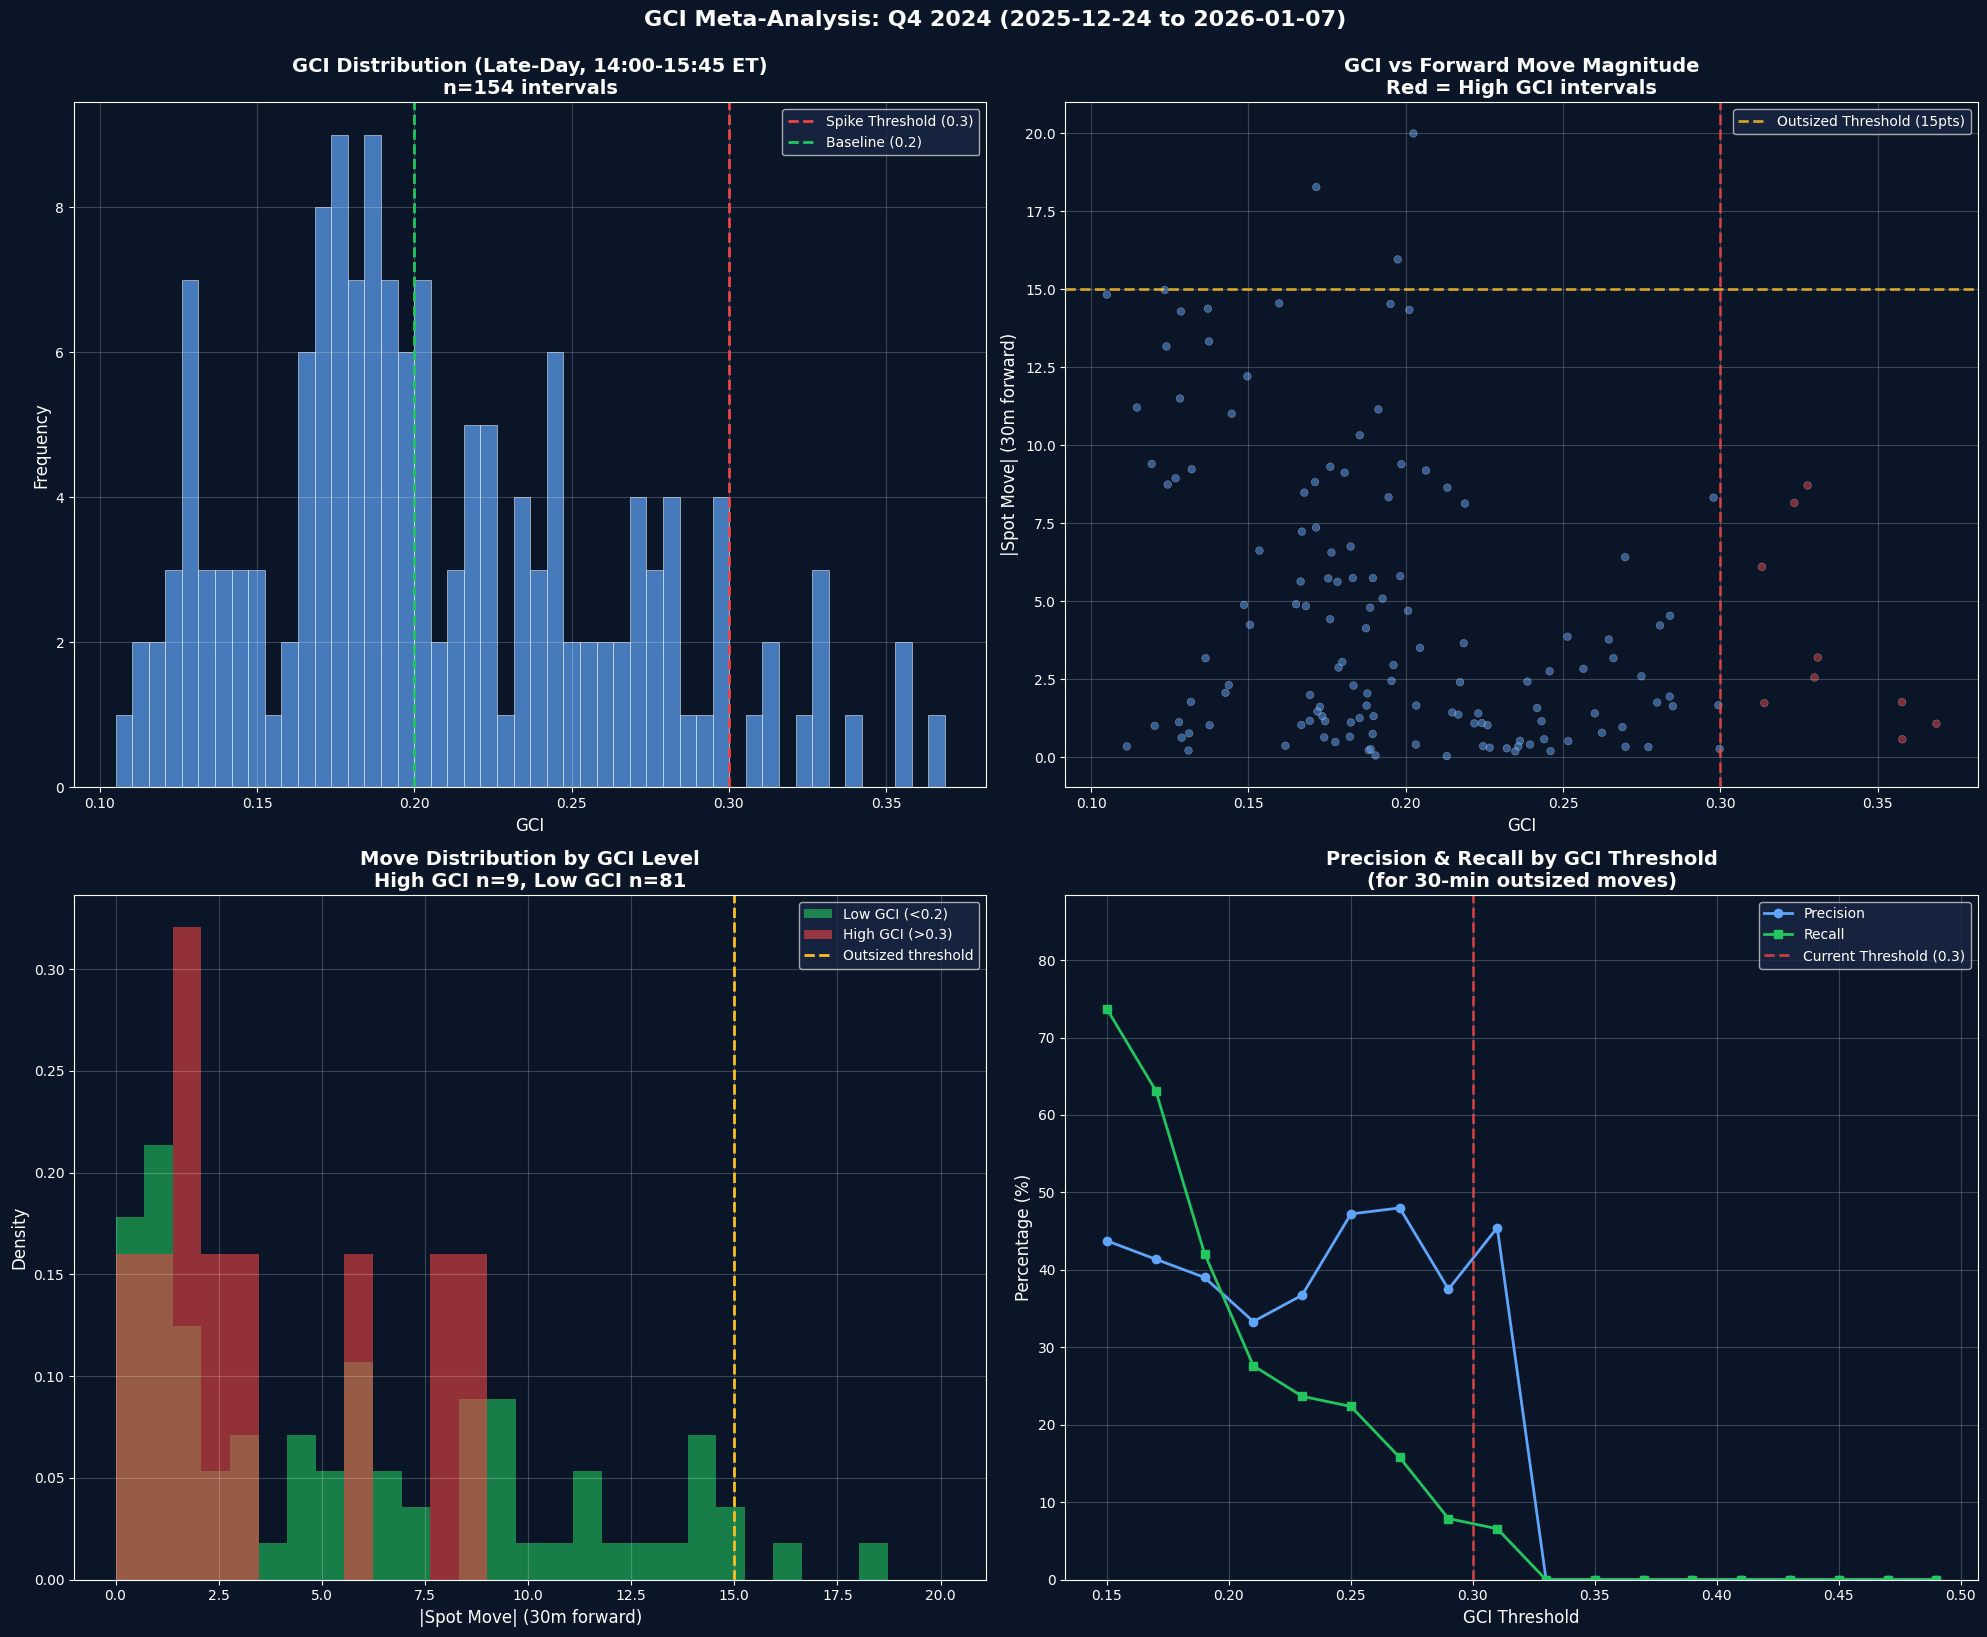

In [17]:
# ============================================================
# VISUALIZATION: GCI DISTRIBUTION & SPIKE OUTCOMES
# ============================================================

if df_late.empty:
    print("No data to visualize!")
else:
    plt.style.use('dark_background')
    fig = plt.figure(figsize=(20, 16))
    fig.patch.set_facecolor('#0a1628')
    
    # Panel 1: GCI Distribution
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.set_facecolor('#0a1628')
    
    gci_vals = df_late['gci'].dropna()
    ax1.hist(gci_vals, bins=50, color='#60a5fa', alpha=0.7, edgecolor='white', linewidth=0.5)
    ax1.axvline(GCI_SPIKE_THRESHOLD, color='#ef4444', linestyle='--', linewidth=2, label=f'Spike Threshold ({GCI_SPIKE_THRESHOLD})')
    ax1.axvline(GCI_BASELINE, color='#22c55e', linestyle='--', linewidth=2, label=f'Baseline ({GCI_BASELINE})')
    
    ax1.set_xlabel('GCI', fontsize=12, color='white')
    ax1.set_ylabel('Frequency', fontsize=12, color='white')
    ax1.set_title(f'GCI Distribution (Late-Day, {LATE_DAY_START}-{LATE_DAY_END} ET)\n'
                  f'n={len(gci_vals):,} intervals', fontsize=14, fontweight='bold', color='white')
    ax1.legend(loc='upper right', fontsize=10, framealpha=0.8, facecolor='#1a2744')
    ax1.tick_params(colors='white')
    ax1.grid(alpha=0.2)
    
    # Panel 2: GCI vs 30-min Move Scatter
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.set_facecolor('#0a1628')
    
    df_plot = df_late[df_late['spot_change_30m'].notna()].copy()
    
    colors = ['#ef4444' if g > GCI_SPIKE_THRESHOLD else '#60a5fa' for g in df_plot['gci']]
    scatter = ax2.scatter(df_plot['gci'], df_plot['spot_change_30m'].abs(), 
                          c=colors, alpha=0.5, s=30, edgecolors='white', linewidths=0.3)
    
    ax2.axvline(GCI_SPIKE_THRESHOLD, color='#ef4444', linestyle='--', linewidth=2, alpha=0.8)
    ax2.axhline(ABS_MOVE_THRESHOLD, color='#fbbf24', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Outsized Threshold ({ABS_MOVE_THRESHOLD}pts)')
    
    ax2.set_xlabel('GCI', fontsize=12, color='white')
    ax2.set_ylabel('|Spot Move| (30m forward)', fontsize=12, color='white')
    ax2.set_title('GCI vs Forward Move Magnitude\n'
                  'Red = High GCI intervals', fontsize=14, fontweight='bold', color='white')
    ax2.legend(loc='upper right', fontsize=10, framealpha=0.8, facecolor='#1a2744')
    ax2.tick_params(colors='white')
    ax2.grid(alpha=0.2)
    
    # Panel 3: Conditional Move Distributions
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.set_facecolor('#0a1628')
    
    high_gci_moves = df_late[df_late['is_high_gci']]['spot_change_30m'].abs().dropna()
    low_gci_moves = df_late[df_late['is_low_gci']]['spot_change_30m'].abs().dropna()
    
    bins = np.linspace(0, max(high_gci_moves.max(), low_gci_moves.max()) * 1.1, 30)
    ax3.hist(low_gci_moves, bins=bins, alpha=0.6, color='#22c55e', label=f'Low GCI (<{GCI_BASELINE})', density=True)
    ax3.hist(high_gci_moves, bins=bins, alpha=0.6, color='#ef4444', label=f'High GCI (>{GCI_SPIKE_THRESHOLD})', density=True)
    ax3.axvline(ABS_MOVE_THRESHOLD, color='#fbbf24', linestyle='--', linewidth=2, label='Outsized threshold')
    
    ax3.set_xlabel('|Spot Move| (30m forward)', fontsize=12, color='white')
    ax3.set_ylabel('Density', fontsize=12, color='white')
    ax3.set_title('Move Distribution by GCI Level\n'
                  f'High GCI n={len(high_gci_moves)}, Low GCI n={len(low_gci_moves)}',
                  fontsize=14, fontweight='bold', color='white')
    ax3.legend(loc='upper right', fontsize=10, framealpha=0.8, facecolor='#1a2744')
    ax3.tick_params(colors='white')
    ax3.grid(alpha=0.2)
    
    # Panel 4: Precision by GCI Threshold
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.set_facecolor('#0a1628')
    
    thresholds = np.arange(0.15, 0.50, 0.02)
    precisions = []
    recalls = []
    n_samples = []
    
    total_outsized = df_late['outsized_30m'].sum()
    
    for thresh in thresholds:
        high_gci = df_late['gci'] > thresh
        outsized = df_late['outsized_30m']
        
        n_high = high_gci.sum()
        tp = (high_gci & outsized).sum()
        
        precision = tp / n_high if n_high > 0 else 0
        recall = tp / total_outsized if total_outsized > 0 else 0
        
        precisions.append(precision * 100)
        recalls.append(recall * 100)
        n_samples.append(n_high)
    
    ax4.plot(thresholds, precisions, 'o-', color='#60a5fa', linewidth=2, markersize=6, label='Precision')
    ax4.plot(thresholds, recalls, 's-', color='#22c55e', linewidth=2, markersize=6, label='Recall')
    ax4.axvline(GCI_SPIKE_THRESHOLD, color='#ef4444', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Current Threshold ({GCI_SPIKE_THRESHOLD})')
    
    ax4.set_xlabel('GCI Threshold', fontsize=12, color='white')
    ax4.set_ylabel('Percentage (%)', fontsize=12, color='white')
    ax4.set_title('Precision & Recall by GCI Threshold\n'
                  '(for 30-min outsized moves)', fontsize=14, fontweight='bold', color='white')
    ax4.legend(loc='upper right', fontsize=10, framealpha=0.8, facecolor='#1a2744')
    ax4.tick_params(colors='white')
    ax4.grid(alpha=0.2)
    ax4.set_ylim(0, max(max(precisions), max(recalls)) * 1.2)
    
    plt.tight_layout()
    fig.suptitle(f'GCI Meta-Analysis: Q4 2024 ({STUDY_START} to {STUDY_END})',
                 fontsize=16, fontweight='bold', color='white', y=1.02)
    
    plt.show()

In [18]:
# ============================================================
# SUMMARY & CONCLUSIONS
# ============================================================

if df_late.empty:
    print("No data to summarize!")
else:
    print("="*70)
    print("GCI META-ANALYSIS SUMMARY")
    print("="*70)
    
    # Calculate key metrics
    n_total_intervals = len(df_late)
    n_days = df_late['trade_date'].nunique()
    n_spikes = df_late['is_spike'].sum()
    n_high_gci = df_late['is_high_gci'].sum()
    
    print(f"\nDATA OVERVIEW:")
    print(f"  Study Period: {STUDY_START} to {STUDY_END}")
    print(f"  Trading Days: {n_days}")
    print(f"  Late-Day Intervals: {n_total_intervals:,}")
    print(f"  GCI Spike Events (crossings): {n_spikes}")
    print(f"  High GCI Intervals (>{GCI_SPIKE_THRESHOLD}): {n_high_gci}")
    
    # Best lookforward window
    best_lift = 0
    best_window = None
    
    for minutes in LOOKFORWARD_MINUTES:
        high_gci = df_late['is_high_gci']
        low_gci = df_late['is_low_gci']
        outsized = df_late[f'outsized_{minutes}m']
        
        p_high = (high_gci & outsized).sum() / high_gci.sum() if high_gci.sum() > 0 else 0
        p_low = (low_gci & outsized).sum() / low_gci.sum() if low_gci.sum() > 0 else 0
        lift = p_high / p_low if p_low > 0 else 0
        
        if lift > best_lift:
            best_lift = lift
            best_window = minutes
    
    print(f"\nBEST PREDICTIVE WINDOW: {best_window} minutes")
    print(f"  Lift: {best_lift:.2f}x")
    
    # Trading implications
    print(f"\n{'='*70}")
    print("TRADING IMPLICATIONS")
    print(f"{'='*70}")
    
    if best_lift > 2.0:
        print("\n✅ STRONG SIGNAL DETECTED")
        print(f"   GCI > {GCI_SPIKE_THRESHOLD} provides {best_lift:.1f}x lift in predicting outsized moves")
        print(f"   Optimal lookforward: {best_window} minutes")
        print("\n   RECOMMENDED STRATEGY:")
        print(f"   - Monitor GCI during {LATE_DAY_START}-{LATE_DAY_END} ET")
        print(f"   - When GCI crosses above {GCI_SPIKE_THRESHOLD}:")
        print(f"     → Buy ATM straddle/strangle")
        print(f"     → Set tight stop (e.g., 20% of premium)")
        print(f"     → Use trailing stop when profitable")
        print(f"     → Exit or re-evaluate after {best_window} minutes")
    elif best_lift > 1.5:
        print("\n⚠️ MODERATE SIGNAL")
        print(f"   GCI provides some predictive value (lift={best_lift:.1f}x)")
        print("   Consider combining with other indicators (PGR, CAR)")
    else:
        print("\n❌ WEAK SIGNAL")
        print("   GCI alone does not reliably predict outsized moves in this sample")
        print("   May need:")
        print("   - Different thresholds")
        print("   - Additional confirmatory signals")
        print("   - Larger sample size")
    
    # Save results
    output_path = Path('../results')
    output_path.mkdir(exist_ok=True)
    
    df_late.to_parquet(output_path / 'gci_late_day_intervals_q4_2024.parquet')
    print(f"\n📁 Results saved to: {output_path.absolute()}")

GCI META-ANALYSIS SUMMARY

DATA OVERVIEW:
  Study Period: 2025-12-24 to 2026-01-07
  Trading Days: 8
  Late-Day Intervals: 176
  GCI Spike Events (crossings): 0
  High GCI Intervals (>0.3): 11

BEST PREDICTIVE WINDOW: 15 minutes
  Lift: 1.80x

TRADING IMPLICATIONS

⚠️ MODERATE SIGNAL
   GCI provides some predictive value (lift=1.8x)
   Consider combining with other indicators (PGR, CAR)

📁 Results saved to: /Users/esaforrian/Documents/GitHub/Hermes/services/gex-analytics/research/gci_meta_analysis/notebooks/../results
